# 3D simple perturbation: first-order Liénard–Wiechert correction

The zeroth-order trajectory is the exact motion of a single charge in the
constant longitudinal external field `E_Z`.  The first-order perturbation
in position and momentum is then obtained by integrating the
Liénard–Wiechert fields produced by all *other* macroparticles along that
zeroth-order trajectory.

## Unit conventions

A hybrid unit system is used for the dynamical variables:

- length          : m
- time            : s
- mass            : MeV / c²
- momentum        : MeV / c
- charge          : units of the elementary-charge magnitude `|e|`
- electric field  : MV / m

`calc_LW_fields` temporarily switches to pure SI (coulombs, volts per
metre, tesla) to evaluate the electromagnetic field formulas; the
returned force is converted back to the hybrid system before being fed
into the state-vector derivative.  Momenta are converted to the
dimensionless `β·γ` only for plotting.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import qmc
from scipy.integrate import solve_ivp

from joblib import Parallel, delayed

plt.rcParams["font.family"] = "serif"

In [12]:
# ---------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------
C_SI         = 299_792_458          # speed of light                    [m/s]
EPSILON_0_SI = 8.8541878128e-12     # vacuum permittivity               [A·s/(V·m)]
E_CHARGE_SI  = 1.602176634e-19      # elementary charge magnitude |e|   [C]
M_E_SI       = 9.1093837015e-31     # electron rest mass                [kg]
M_E          = 0.511                # electron rest mass                [MeV/c²]
Q_E          = -1.0                 # electron charge                   [|e|]

In [ ]:
# ---------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------
E_Z              = -1.0              # longitudinal external E-field     [MV/m]
TOTAL_CHARGE_SI  = -1e-12            # total bunch charge                [C]
N_PARTICLES      = 2**8              # number of macroparticles          [1]
T_END            = 1.2e-8           # end of integration                [s]

USE_CIC_SOFTENING = True             # whether to use softening in the CIC force calculation
R_SOFT = 0.00005                     # softening radius for CIC (if enabled)  [m]

# ---------------------------------------------------------------------
# Derived quantities
# ---------------------------------------------------------------------
N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI) / E_CHARGE_SI    # real electrons in the bunch
MACRO_WEIGHT     = N_REAL_PARTICLES / N_PARTICLES           # real particles per macroparticle

# Signed macroparticle charge / mass for the pure-SI L-W field calculation.
Q_MACRO_SI = Q_E * MACRO_WEIGHT * E_CHARGE_SI               # [C]
M_MACRO_SI = MACRO_WEIGHT * M_E_SI                          # [kg]

In [14]:
# ---------------------------------------------------------------------
# Initial Distribution
# ---------------------------------------------------------------------

# PARAMETERS
Z_0 = 0. # initial z position of reference particle in m

ENERGY_0 = 1e-2 # initial kinetic energy of reference particle in MeV

SIMPLE_SIGMA_X = 1e-3 # standard deviation of initial x position in m
SIMPLE_SIGMA_Y = 1e-3 # standard deviation of initial y position in m
SIMPLE_SIGMA_Z = 1e-3 # standard deviation of initial z position in m

SIMPLE_SIGMA_PX_BG = 1e-6 # standard deviation of initial x momentum in 1 (betagamma)
SIMPLE_SIGMA_PY_BG = 1e-6 # standard deviation of initial y momentum in 1 (betagamma)
SIMPLE_SIGMA_PZ_BG = 1e-6 # standard deviation of initial z momentum in 1 (betagamma)

# DERIVED QUANTITIES
GAMMA_0 = (ENERGY_0 + M_E) / M_E # initial Lorentz factor of reference particle
BETA_0 = np.sqrt(1 - 1 / GAMMA_0**2) # initial beta of reference particle
PZ_0 = BETA_0 * GAMMA_0 * M_E # initial momentum of reference particle in MeV/c

SIMPLE_POSITION_0 = np.array((0., 0., Z_0)) # initial position (of reference particle) in m
SIMPLE_MOMENTUM_0 = np.array((0., 0., PZ_0)) # initial momentum in MeV/c

BG_to_P = lambda bg: bg * M_E # function to transform momentum from betagamma to particle units

SIMPLE_POSITION_SIGMA_0 = np.array((SIMPLE_SIGMA_X, SIMPLE_SIGMA_Y, SIMPLE_SIGMA_Z)) # in m
SIMPLE_MOMENTUM_SIGMA_0 = np.array((BG_to_P(SIMPLE_SIGMA_PX_BG), BG_to_P(SIMPLE_SIGMA_PY_BG), BG_to_P(SIMPLE_SIGMA_PZ_BG))) # in MeV/c



In [15]:
def p_to_betagamma(p):
    """Convert momentum from [MeV/c] to the dimensionless ``β·γ``.

    Parameters
    ----------
    p : array_like
        Momentum in MeV/c.

    Returns
    -------
    array_like
        Same shape as ``p``, dimensionless.
    """
    return p / M_E


def sample_ellipsoid_qmc(mean, radii, n_particles):
    """Quasi-Monte-Carlo sampling of a 3D ellipsoid using a Sobol sequence.

    Produces a low-discrepancy, clump-free, uniform-density set of points
    inside the ellipsoid centred at ``mean`` with semi-axes ``radii``.

    Parameters
    ----------
    mean : array_like, shape (3,)
        Centre of the ellipsoid [m].
    radii : array_like, shape (3,)
        Semi-axis lengths [m].
    n_particles : int
        Number of samples (best results when this is a power of two).

    Returns
    -------
    points : ndarray, shape (n_particles, 3)
        Sampled positions [m].
    """
    sampler = qmc.Sobol(d=3, scramble=False)
    u = sampler.random(n=n_particles)
    u1, u2, u3 = u[:, 0], u[:, 1], u[:, 2]

    # Uniform density inside the unit ball: r ~ u1^(1/3) absorbs the radial
    # Jacobian; cos(θ) uniform in [-1, 1] gives a uniform direction.
    r         = u1 ** (1.0 / 3.0)
    cos_theta = 1.0 - 2.0 * u2
    sin_theta = np.sqrt(1.0 - cos_theta ** 2)
    phi       = 2.0 * np.pi * u3

    x_sphere = r * sin_theta * np.cos(phi)
    y_sphere = r * sin_theta * np.sin(phi)
    z_sphere = r * cos_theta

    points = np.empty((n_particles, 3))
    points[:, 0] = mean[0] + radii[0] * x_sphere
    points[:, 1] = mean[1] + radii[1] * y_sphere
    points[:, 2] = mean[2] + radii[2] * z_sphere
    return points

In [16]:
# Reference-simulation data.
#   column  0     time           [s]
#   columns 1..3  mean position  (x, y, z)   [m]
#   columns 4..6  position sigma (x, y, z)   [m]
#   columns 7..9  mean momentum  (x, y, z)   [MeV/c]
data_3d_simple = np.loadtxt("./data/3d_data_simple.csv", delimiter=",")

data_times = data_3d_simple[:, 0]
data_position_means_si  = data_3d_simple[:, 1:4]    # [m]
data_position_sigmas_si = data_3d_simple[:, 4:7]    # [m]
data_momentum_means_pp  = data_3d_simple[:, 7:10]   # [MeV/c]
data_momentum_sigmas_pp = data_3d_simple[:, 10:]    # [MeV/c]

def plot_data(ax, x_analytic, y_analytic, x_data, y_data):
    y_data_interp = np.interp(x_analytic, x_data, y_data)

    ax.plot(x_analytic, y_data_interp, label="Simulation Data", color="black", linestyle="--", linewidth=0.5)
    ax.legend(loc="upper left")

    ax_diff = ax.twinx()
    y_diff = np.abs(y_data_interp - y_analytic)
    ax_diff.plot(x_analytic, y_diff, label="Difference \nSimulation - Analytic", color="red", linewidth=0.5)
    ax_diff.set_ylabel(ax.get_ylabel(), color="red")
    ax_diff.tick_params(axis='y', labelcolor="red")
    ax_diff.legend(loc="upper right")

In [17]:
def get_0th_trajectory(t, r0, p0):
    """Exact zeroth-order trajectory in the constant external field ``E_Z``.

    Parameters
    ----------
    t : float
        Observation time [s].
    r0 : ndarray, shape (3,)
        Initial position [m].
    p0 : ndarray, shape (3,)
        Initial momentum [MeV/c].

    Returns
    -------
    r_t : ndarray, shape (3,)
        Position at ``t``                                 [m].
    p_t : ndarray, shape (3,)
        Momentum at ``t``                                 [MeV/c].
    gamma_t : float
        Lorentz factor at ``t``                           [1].
    """
    # fsolve passes t as a length-1 array; coerce to scalar.
    t = float(np.atleast_1d(t)[0])

    # Force in hybrid units:  F = Q_E * E_Z * c_SI  has units of [MeV/c per s]
    pz_t = p0[2] + (Q_E * E_Z * C_SI) * t
    p_t = np.array([p0[0], p0[1], pz_t])

    gamma_t = np.sqrt(1.0 + np.sum(p_t**2) / M_E**2)
    gamma_0 = np.sqrt(1.0 + np.sum(p0**2) / M_E**2)
    
    # Transversal Mass
    m_perp = np.sqrt(M_E**2 + p0[0]**2 + p0[1]**2)

    
    # Displacement of x/y are solved over arcsinh, while z is given by the gamma difference
    arsinh_term_t = np.arcsinh(pz_t / m_perp)
    arsinh_term_0 = np.arcsinh(p0[2] / m_perp)
    arsinh_diff = arsinh_term_t - arsinh_term_0
    
    delta_x = (p0[0] / (Q_E * E_Z)) * arsinh_diff
    delta_y = (p0[1] / (Q_E * E_Z)) * arsinh_diff
    
    delta_z = (M_E / (Q_E * E_Z)) * (gamma_t - gamma_0)


    r_t = np.array([r0[0] + delta_x, r0[1] + delta_y, r0[2] + delta_z])

    return r_t, p_t, gamma_t

In [18]:
def t_ret(t_obs, r_obs, r0_sources, p0_sources, max_iter=60, atol=1e-14):
    """Retarded times for *all* sources at once (safe-guarded Newton).

    Solves, independently for every source ``i`` and in parallel via
    numpy, the light-cone condition

        f(t_r) ≡ c · (t_obs - t_r) - |r_obs - r_src(t_r)| = 0.

    Each source ``i`` now carries its own initial 3-momentum
    ``p0_sources[i] = (px, py, pz)``; transverse momenta are conserved by
    the external longitudinal field, so the source trajectory is

        Δx = (px / (Q·E)) · [arsinh(pz_tr / m_⊥) - arsinh(pz_0 / m_⊥)]
        Δy = (py / (Q·E)) · [arsinh(pz_tr / m_⊥) - arsinh(pz_0 / m_⊥)]
        Δz = (M_E / (Q·E)) · (γ(t_r) - γ(0))

    with ``m_⊥ = √(M_E² + px² + py²)`` and ``pz_tr = pz_0 + F_z · t_r``.

    ``f`` is strictly monotonically decreasing on ``[0, t_obs]`` with
    ``f(0) > 0`` and ``f(t_obs) = -|r_obs - r_src(t_obs)| < 0``, so the
    root is unique.  For sources slightly behind an ultra-relativistic
    target, ``f'(t_r) = -c + (R_vec · v_src) / R`` collapses to ~0 (the
    source nearly co-moves with the light signal), which makes naive
    Newton overshoot wildly.  We therefore maintain a bracket
    ``[a, b]`` with ``f(a) > 0``, ``f(b) < 0`` and accept the Newton
    step only when it stays inside the bracket and reduces the
    bracket width by at least a factor of two; otherwise we bisect.
    This mirrors what MINPACK's HYBRD does internally.

    Parameters
    ----------
    t_obs : float
        Observer time [s].
    r_obs : ndarray, shape (3,)
        Observer position [m].
    r0_sources : ndarray, shape (N, 3)
        Initial positions of the source particles [m].
    p0_sources : ndarray, shape (N, 3)
        Initial momenta of the source particles [MeV/c].  ``px`` and
        ``py`` are conserved; ``pz`` evolves under the external field.
    max_iter : int
        Maximum hybrid Newton/bisection steps.
    atol : float
        Absolute tolerance on the light-cone residual [m].

    Returns
    -------
    t_r : ndarray, shape (N,)
        Retarded times [s].
    """
    F_z  = Q_E * E_Z * C_SI                                  # [MeV/c per s]
    coef = 1.0 / (Q_E * E_Z)                                 # used in Δr formulas

    # Per-source kinematic invariants (constants in t_r).
    px0  = p0_sources[:, 0]                                  # (N,)
    py0  = p0_sources[:, 1]                                  # (N,)
    pz0  = p0_sources[:, 2]                                  # (N,)
    p_perp_sq = px0 * px0 + py0 * py0                        # (N,)
    m_perp    = np.sqrt(M_E * M_E + p_perp_sq)               # (N,) transverse mass
    gamma_0   = np.sqrt(1.0 + (p_perp_sq + pz0 * pz0) / M_E ** 2)
    arsinh_0  = np.arcsinh(pz0 / m_perp)                     # (N,)

    # Observer minus source initial position (before Δr subtraction).
    x_off = r_obs[0] - r0_sources[:, 0]                      # (N,)
    y_off = r_obs[1] - r0_sources[:, 1]                      # (N,)
    z_off = r_obs[2] - r0_sources[:, 2]                      # (N,)

    def f_and_R(t_r):
        """Evaluate f(t_r) and the R-vector / scalar at t_r."""
        pz_tr      = pz0 + F_z * t_r
        gamma_tr   = np.sqrt(1.0 + (p_perp_sq + pz_tr * pz_tr) / M_E ** 2)
        arsinh_dif = np.arcsinh(pz_tr / m_perp) - arsinh_0
        dx_src     = (px0 * coef) * arsinh_dif
        dy_src     = (py0 * coef) * arsinh_dif
        dz_src     = (M_E * coef) * (gamma_tr - gamma_0)

        Rx = x_off - dx_src
        Ry = y_off - dy_src
        Rz = z_off - dz_src
        R  = np.sqrt(Rx * Rx + Ry * Ry + Rz * Rz)
        f  = C_SI * (t_obs - t_r) - R
        return f, R, Rx, Ry, Rz, pz_tr, gamma_tr

    # Bracket: a < root < b ;  f(a) > 0  and  f(b) < 0.
    N = r0_sources.shape[0]
    a = np.zeros(N)
    b = np.full(N, t_obs)

    # Conservative initial guess: light travel from source's *current* pos.
    pz_now      = pz0 + F_z * t_obs
    gamma_now   = np.sqrt(1.0 + (p_perp_sq + pz_now * pz_now) / M_E ** 2)
    arsinh_diff = np.arcsinh(pz_now / m_perp) - arsinh_0
    dx_now      = (px0 * coef) * arsinh_diff
    dy_now      = (py0 * coef) * arsinh_diff
    dz_now      = (M_E * coef) * (gamma_now - gamma_0)
    Rx_now      = x_off - dx_now
    Ry_now      = y_off - dy_now
    Rz_now      = z_off - dz_now
    R_now       = np.sqrt(Rx_now ** 2 + Ry_now ** 2 + Rz_now ** 2)
    t_r         = t_obs - R_now / C_SI
    t_r         = np.clip(t_r, a + 1e-30, b - 1e-30)

    for _ in range(max_iter):
        f, R, Rx, Ry, Rz, pz_tr, gamma_tr = f_and_R(t_r)
        if np.max(np.abs(f)) < atol:
            break

        # Tighten the bracket using the sign of f.
        pos = f > 0.0
        a   = np.where(pos, t_r, a)
        b   = np.where(pos, b,   t_r)

        # Newton step.  f' = -c + (R_vec · v_src) / R.
        inv_gm = 1.0 / (gamma_tr * M_E)
        v_x_tr = (px0   * inv_gm) * C_SI
        v_y_tr = (py0   * inv_gm) * C_SI
        v_z_tr = (pz_tr * inv_gm) * C_SI
        f_prime = -C_SI + (Rx * v_x_tr + Ry * v_y_tr + Rz * v_z_tr) / R
        # Guard against degenerate f' ~ 0 (ultra-relativistic, behind-target).
        f_prime = np.where(np.abs(f_prime) < 1e-30, -C_SI, f_prime)
        t_r_newton = t_r - f / f_prime

        # Accept Newton only when it stays strictly inside the bracket
        # and reduces width meaningfully; otherwise bisect.
        bracket_width = b - a
        in_bracket    = (t_r_newton > a) & (t_r_newton < b)
        good_progress = np.abs(t_r_newton - t_r) < 0.5 * bracket_width
        use_newton    = in_bracket & good_progress
        t_r = np.where(use_newton, t_r_newton, 0.5 * (a + b))

    return t_r


def calc_LW_fields(t_obs, r_obs, r0_sources, p0_sources):
    """Total Liénard–Wiechert E and B fields summed over N sources.

    Fully vectorised: every cross product, norm, dot product, and the
    Plummer softening are evaluated as NumPy operations on arrays of
    shape ``(N, 3)`` and ``(N,)``, replacing any Python-for-loop over
    individual sources.

    Each source carries its own initial 3-momentum
    ``p0_sources[i]``; transverse components ``px``, ``py`` are
    conserved by the external longitudinal field, while ``pz`` evolves
    as ``pz(t_r) = pz_0 + F_z · t_r``.  Because the sources now have
    transverse velocity, the relativistic acceleration ``β̇`` is the
    *full* vectorial expression

        β̇ = [F_ext − β (β · F_ext)] / (m c γ)

    rather than the longitudinal-only ``F / (γ³ m c)``.  The transverse
    component of ``β̇`` is what allows transverse radiation (synchrotron
    cross terms) to enter the fields.

    Internally evaluated in pure SI (to avoid having to track all unit
    conversions inside the electromagnetic field expressions); the
    returned fields are in SI as well — volts per metre and tesla — and
    are converted back by the caller.

    Parameters
    ----------
    t_obs : float
        Observer time [s].
    r_obs : ndarray, shape (3,)
        Observer position [m].
    r0_sources : ndarray, shape (N, 3)
        Initial positions of the source particles [m].  Caller is
        responsible for excluding any self-source.
    p0_sources : ndarray, shape (N, 3)
        Initial 3-momenta of the source particles [MeV/c].

    Returns
    -------
    E_field_si : ndarray, shape (3,)
        Sum of source E-fields at the observer [V/m].
    B_field_si : ndarray, shape (3,)
        Sum of source B-fields at the observer [T].
    """
    # Vectorised retarded times (one per source).
    t_r = t_ret(t_obs, r_obs, r0_sources, p0_sources)                # (N,)

    # Per-source kinematic invariants.
    px0  = p0_sources[:, 0]                                          # (N,)
    py0  = p0_sources[:, 1]                                          # (N,)
    pz0  = p0_sources[:, 2]                                          # (N,)
    p_perp_sq = px0 * px0 + py0 * py0                                # (N,)
    m_perp    = np.sqrt(M_E * M_E + p_perp_sq)                       # (N,)
    gamma_0   = np.sqrt(1.0 + (p_perp_sq + pz0 * pz0) / M_E ** 2)    # (N,)
    arsinh_0  = np.arcsinh(pz0 / m_perp)                             # (N,)

    # Zeroth-order kinematics at the retarded time (vectorised, full 3D).
    F_z       = Q_E * E_Z * C_SI                                     # scalar
    coef      = 1.0 / (Q_E * E_Z)
    pz_src    = pz0 + F_z * t_r                                      # (N,)
    gamma_src = np.sqrt(1.0 + (p_perp_sq + pz_src * pz_src) / M_E ** 2)
    arsinh_d  = np.arcsinh(pz_src / m_perp) - arsinh_0               # (N,)
    dx_src    = (px0 * coef) * arsinh_d                              # (N,)
    dy_src    = (py0 * coef) * arsinh_d                              # (N,)
    dz_src    = (M_E * coef) * (gamma_src - gamma_0)                 # (N,)

    # Geometry: R_vec = r_obs - r_src(t_r),  (N, 3) and (N,).
    R_vec = np.empty_like(r0_sources)
    R_vec[:, 0] = r_obs[0] - r0_sources[:, 0] - dx_src
    R_vec[:, 1] = r_obs[1] - r0_sources[:, 1] - dy_src
    R_vec[:, 2] = r_obs[2] - r0_sources[:, 2] - dz_src
    R_mag = np.linalg.norm(R_vec, axis=1)                            # (N,)
    n_vec = R_vec / R_mag[:, None]                                   # (N, 3)

    # Full 3D source velocity (β-vector) at the retarded time.
    inv_gm = 1.0 / (gamma_src * M_E)                                 # (N,)
    beta_vec = np.empty_like(R_vec)
    beta_vec[:, 0] = px0   * inv_gm
    beta_vec[:, 1] = py0   * inv_gm
    beta_vec[:, 2] = pz_src * inv_gm                                 # (N, 3)

    # SOFTENING to Cloud-in-Cell — preventing arbitrarily high forces
    # between neighbouring particles.  The unit-vector direction stays
    # un-softened; only the *radial decay* is regularised.
    if USE_CIC_SOFTENING:
        R_mag_soft_sq = R_mag * R_mag + R_SOFT * R_SOFT
        R_mag_soft    = np.sqrt(R_mag_soft_sq)
    else:
        R_mag_soft_sq = R_mag * R_mag
        R_mag_soft    = R_mag

    # Full vectorial relativistic acceleration in SI:
    #   β̇ = (F_ext − β (β · F_ext)) / (m c γ)
    # with F_ext = (0, 0, q_elec · E_z_SI).
    E_ext_si  = E_Z * 1e6                                            # [V/m]
    q_elec_si = Q_E * E_CHARGE_SI                                    # [C]
    m_elec_si = M_E_SI                                               # [kg]
    F_z_si    = q_elec_si * E_ext_si                                 # scalar [N]

    beta_dot_F = beta_vec[:, 2] * F_z_si                             # (N,)
    dot_beta_vec = np.empty_like(R_vec)
    dot_beta_vec[:, 0] = -beta_vec[:, 0] * beta_dot_F
    dot_beta_vec[:, 1] = -beta_vec[:, 1] * beta_dot_F
    dot_beta_vec[:, 2] = F_z_si - beta_vec[:, 2] * beta_dot_F
    dot_beta_vec /= (m_elec_si * C_SI * gamma_src[:, None])          # (N, 3)

    one_minus_beta_n  = 1.0 - np.einsum("ij,ij->i", beta_vec, n_vec)   # (N,)
    one_minus_beta_n3 = one_minus_beta_n ** 3                          # (N,)

    # Velocity (near) field, (N, 3).
    term_velocity = (n_vec - beta_vec) / (
        gamma_src[:, None] ** 2 * one_minus_beta_n3[:, None] * R_mag_soft_sq[:, None]
    )

    # Acceleration (radiation) field, (N, 3).
    cross_accel = np.cross(n_vec - beta_vec, dot_beta_vec)
    term_accel  = np.cross(n_vec, cross_accel) / (
        C_SI * one_minus_beta_n3[:, None] * R_mag_soft[:, None]
    )

    # Per-source E and B, then summed.
    E_each = (Q_MACRO_SI / (4.0 * np.pi * EPSILON_0_SI)) * (
        term_velocity + term_accel
    )                                                                  # (N, 3) [V/m]
    B_each = np.cross(n_vec, E_each) / C_SI                            # (N, 3) [T]
    return E_each.sum(axis=0), B_each.sum(axis=0)


def get_1st_order_perturbation(t_end, r0_target, p0_target,
                               all_r0_sources, all_p0_sources):
    """Integrate the first-order position and momentum perturbation.

    Inner source-summation is fully vectorised by :func:`t_ret` and
    :func:`calc_LW_fields`, so one ODE step costs O(1) NumPy dispatches
    instead of O(N) Python iterations.

    Each particle now carries its own initial 3-momentum, so the
    zeroth-order target velocity is fully 3D and the velocity kick from
    the momentum perturbation is given by the *full relativistic mass
    tensor*

        v¹ᵢ = (p¹ᵢ − p⁰ᵢ (p⁰·p¹)/(M_E γ)²) / (M_E γ),

    which reduces to the previous ``γ`` / ``γ³`` formulas for purely
    longitudinal ``p⁰`` and correctly couples transverse / longitudinal
    perturbations when ``p⁰`` has transverse components.

    Parameters
    ----------
    t_end : float
        Final integration time [s].
    r0_target : ndarray, shape (3,)
        Initial (zeroth-order) position of the target particle [m].
    p0_target : ndarray, shape (3,)
        Initial 3-momentum of the target particle [MeV/c].
    all_r0_sources : ndarray, shape (N, 3)
        Initial positions of the source macroparticles [m].  The target
        itself is skipped inside the integrand.
    all_p0_sources : ndarray, shape (N, 3)
        Initial 3-momenta of the source macroparticles [MeV/c].

    Returns
    -------
    t : ndarray
        Adaptive solver time grid [s].
    r1_t : ndarray, shape (3, len(t))
        Position perturbation [m].
    p1_t : ndarray, shape (3, len(t))
        Momentum perturbation [MeV/c].
    """
    # Build the self-excluded source arrays once per target.  We compare
    # both r0 and p0 to be robust if two particles happen to share a
    # position (won't happen with the QMC sampler, but cheap to check).
    same_r = np.all(np.isclose(all_r0_sources, r0_target), axis=1)
    same_p = np.all(np.isclose(all_p0_sources, p0_target), axis=1)
    is_self    = same_r & same_p
    r0_src_eff = all_r0_sources[~is_self]                           # (N − 1, 3)
    p0_src_eff = all_p0_sources[~is_self]                           # (N − 1, 3)

    # SI→hybrid momentum conversion.  1 MeV/c = 1e6 · |e| / c_SI  kg·m/s, so
    #     dp_hybrid/dt  =  F_SI / p_si_per_hybrid    [MeV/c per s].
    p_si_per_hybrid = (1e6 * E_CHARGE_SI) / C_SI         # [kg·m/s per (MeV/c)]
    q_target_si     = Q_E * E_CHARGE_SI                  # one test electron [C]

    def perturbation_derivatives(t, Y):
        # State Y = [p1_x, p1_y, p1_z, r1_x, r1_y, r1_z].
        p1 = Y[0:3]

        # Zeroth-order kinematics of the target (full 3D momentum now).
        r_target_t, p_target_t, gamma_target_t = get_0th_trajectory(
            t, r0_target, p0_target
        )
        # v⁰ = p⁰ / (γ M_E) · c   in SI [m/s], shape (3,).
        v_target_si = (p_target_t / (gamma_target_t * M_E)) * C_SI

        # Vectorised L-W field summation over every other source.
        E_tot_si, B_tot_si = calc_LW_fields(
            t, r_target_t, r0_src_eff, p0_src_eff,
        )

        # Lorentz force in SI [N] and conversion to MeV/c per s.
        F_si   = q_target_si * (E_tot_si + np.cross(v_target_si, B_tot_si))
        dp1_dt = F_si / p_si_per_hybrid

        # Velocity kick via the full relativistic mass tensor (impulse
        # cross-talk between longitudinal and transverse directions).
        #     v¹ = (p¹ − p⁰ (p⁰·p¹) / (M_E γ)²) / (M_E γ)
        # In hybrid units  p / M_E gives c-units, so · C_SI yields m/s.
        m_gamma     = M_E * gamma_target_t
        m_gamma_sq  = m_gamma * m_gamma
        p0_dot_p1   = np.dot(p_target_t, p1)
        v1_hybrid   = (p1 - p_target_t * (p0_dot_p1 / m_gamma_sq)) / m_gamma
        dr1_dt      = v1_hybrid * C_SI

        return np.concatenate((dp1_dt, dr1_dt))

    # No perturbation at t = 0.
    Y0 = np.zeros(6)
    sol = solve_ivp(
        perturbation_derivatives,
        [0.0, t_end],
        Y0,
        method='RK45',
        rtol=1e-6,
        atol=1e-9,
    )
    p1_t = sol.y[0:3, :]
    r1_t = sol.y[3:6, :]
    return sol.t, r1_t, p1_t

In [19]:
# Initial conditions taken from the first time stamp of the reference data.
# Sampling radii are sqrt(5) * sigma to match a uniform ellipsoid with the
# same RMS as the reference Gaussian distribution.
#
# Although sampled determistically, the values (positions, momenta) are scrambled over the indices
#  -> no correlation of positions and momenta
r0_particles = sample_ellipsoid_qmc(
    mean        = SIMPLE_POSITION_0,
    radii       = np.sqrt(5.0) * SIMPLE_POSITION_SIGMA_0,
    # mean        = data_position_means_si[0],
    # radii       = np.sqrt(5.0) * data_position_sigmas_si[0],
    n_particles = N_PARTICLES,
)
p0_particles = sample_ellipsoid_qmc(
    mean        = SIMPLE_MOMENTUM_0,
    radii       = np.sqrt(5.0) * SIMPLE_MOMENTUM_SIGMA_0,
    # mean        = data_momentum_means_pp[0],
    # radii       = np.sqrt(5.0) * data_momentum_sigmas_pp[0],
    n_particles = N_PARTICLES,
)


# Parallelise the outer target loop.  Each task is a self-contained
# perturbation integration whose heavy lifting is now NumPy / BLAS (the
# vectorised L-W field summation), which releases the GIL — threads
# therefore give near-linear speed-up without any pickling overhead and
# work cleanly inside a Jupyter / Windows environment.
def _solve_one_target(r0_target, p0_target):
    return get_1st_order_perturbation(
        T_END,
        r0_target,
        p0_target,
        r0_particles,
        p0_particles,
    )

results = Parallel(n_jobs=-1, prefer="threads", verbose=10)(
    delayed(_solve_one_target)(r0_target, p0_target) for r0_target, p0_target in zip(r0_particles, p0_particles)
)

times1_particles = [r[0] for r in results]
r1_t_particles   = [r[1] for r in results]
p1_t_particles   = [r[2] for r in results]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   32.1s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   41.4s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:   48.0s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:   56.6s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elaps

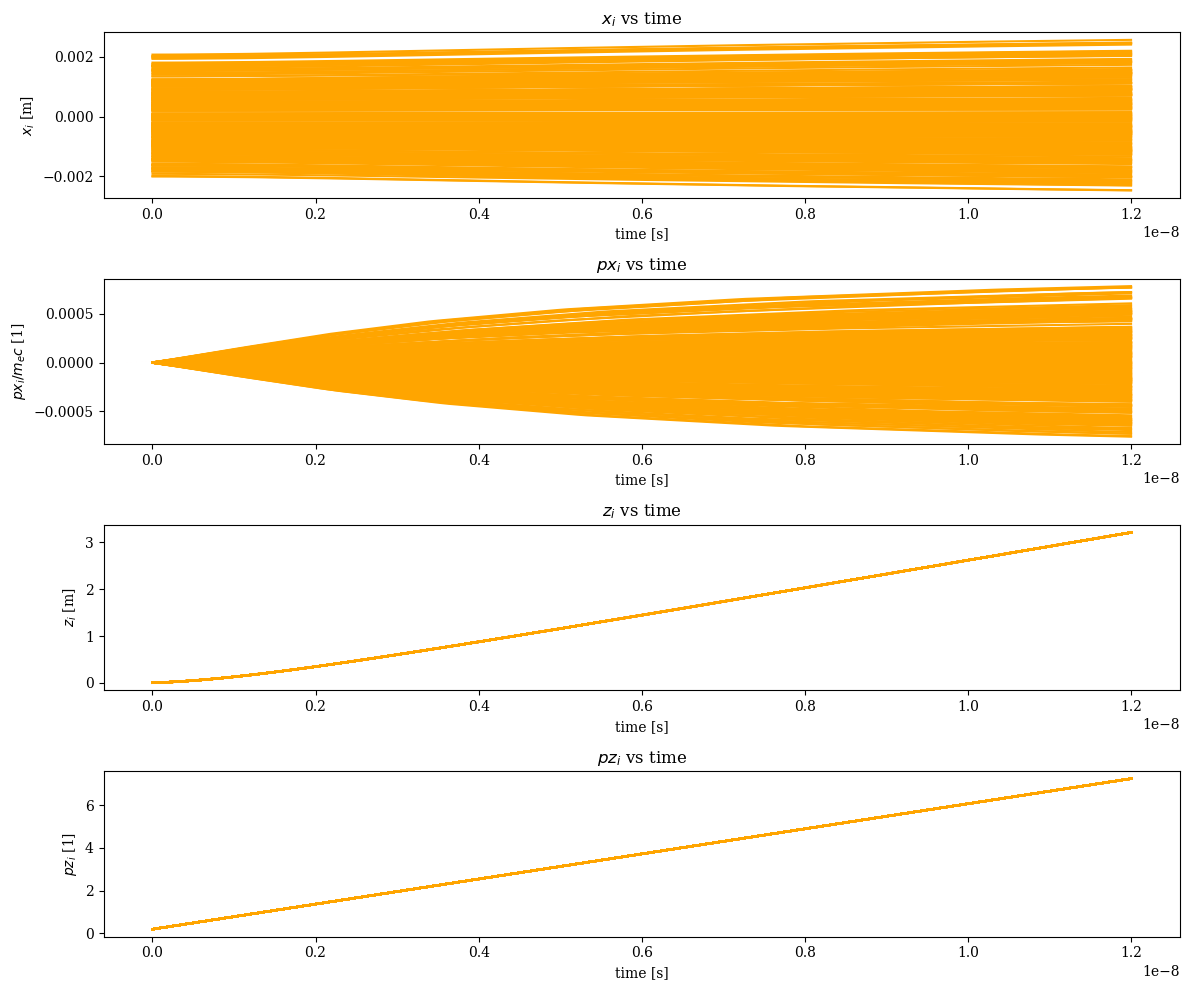

In [20]:
# Interpolate the perturbation onto a common time grid and add the
# zeroth-order solution.  Transverse zeroth-order position and momentum
# are zero by construction (only the longitudinal external field acts).
num_targets = len(r1_t_particles)
times = np.linspace(0.0, T_END, 100)

r_t_particles = np.zeros((num_targets, len(times), 3))   # [m]
p_t_particles = np.zeros((num_targets, len(times), 3))   # [MeV/c]

for target_idx in range(num_targets):
    r0_0   = r0_particles[target_idx]
    p0_0   = p0_particles[target_idx]
    times1 = times1_particles[target_idx]
    r1_t   = r1_t_particles[target_idx]
    p1_t   = p1_t_particles[target_idx]

    r1_x_interp = np.interp(times, times1, r1_t[0, :])
    r1_y_interp = np.interp(times, times1, r1_t[1, :])
    r1_z_interp = np.interp(times, times1, r1_t[2, :])
    p1_x_interp = np.interp(times, times1, p1_t[0, :])
    p1_y_interp = np.interp(times, times1, p1_t[1, :])
    p1_z_interp = np.interp(times, times1, p1_t[2, :])

    for t_idx, t in enumerate(times):
        r0, p0, _ = get_0th_trajectory(t, r0_0, p0_0)
        r_t_particles[target_idx, t_idx, 0] = r0[0] + r1_x_interp[t_idx]
        r_t_particles[target_idx, t_idx, 1] = r0[1] + r1_y_interp[t_idx]
        r_t_particles[target_idx, t_idx, 2] = r0[2] + r1_z_interp[t_idx]
        p_t_particles[target_idx, t_idx, 0] = p0[0] + p1_x_interp[t_idx]
        p_t_particles[target_idx, t_idx, 1] = p0[1] + p1_y_interp[t_idx]
        p_t_particles[target_idx, t_idx, 2] = p0[2] + p1_z_interp[t_idx]

fig, axes = plt.subplots(4, figsize=(12, 10))
for i in range(num_targets):
    axes[0].plot(times, r_t_particles[i, :, 0],                 color='orange')
    axes[1].plot(times, p_to_betagamma(p_t_particles[i, :, 0]), color='orange')
    
    axes[2].plot(times, r_t_particles[i, :, 2],                 color='orange')
    axes[3].plot(times, p_to_betagamma(p_t_particles[i, :, 2]), color='orange')


axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("$x_i$ [m]")
axes[0].set_title("$x_i$ vs time")

axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("$px_i / m_e c$ [1]")
axes[1].set_title("$px_i$ vs time")


axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("$z_i$ [m]")
axes[2].set_title("$z_i$ vs time")

axes[3].set_xlabel("time [s]")
axes[3].set_ylabel("$pz_i$ [1]")
axes[3].set_title("$pz_i$ vs time")

fig.tight_layout()

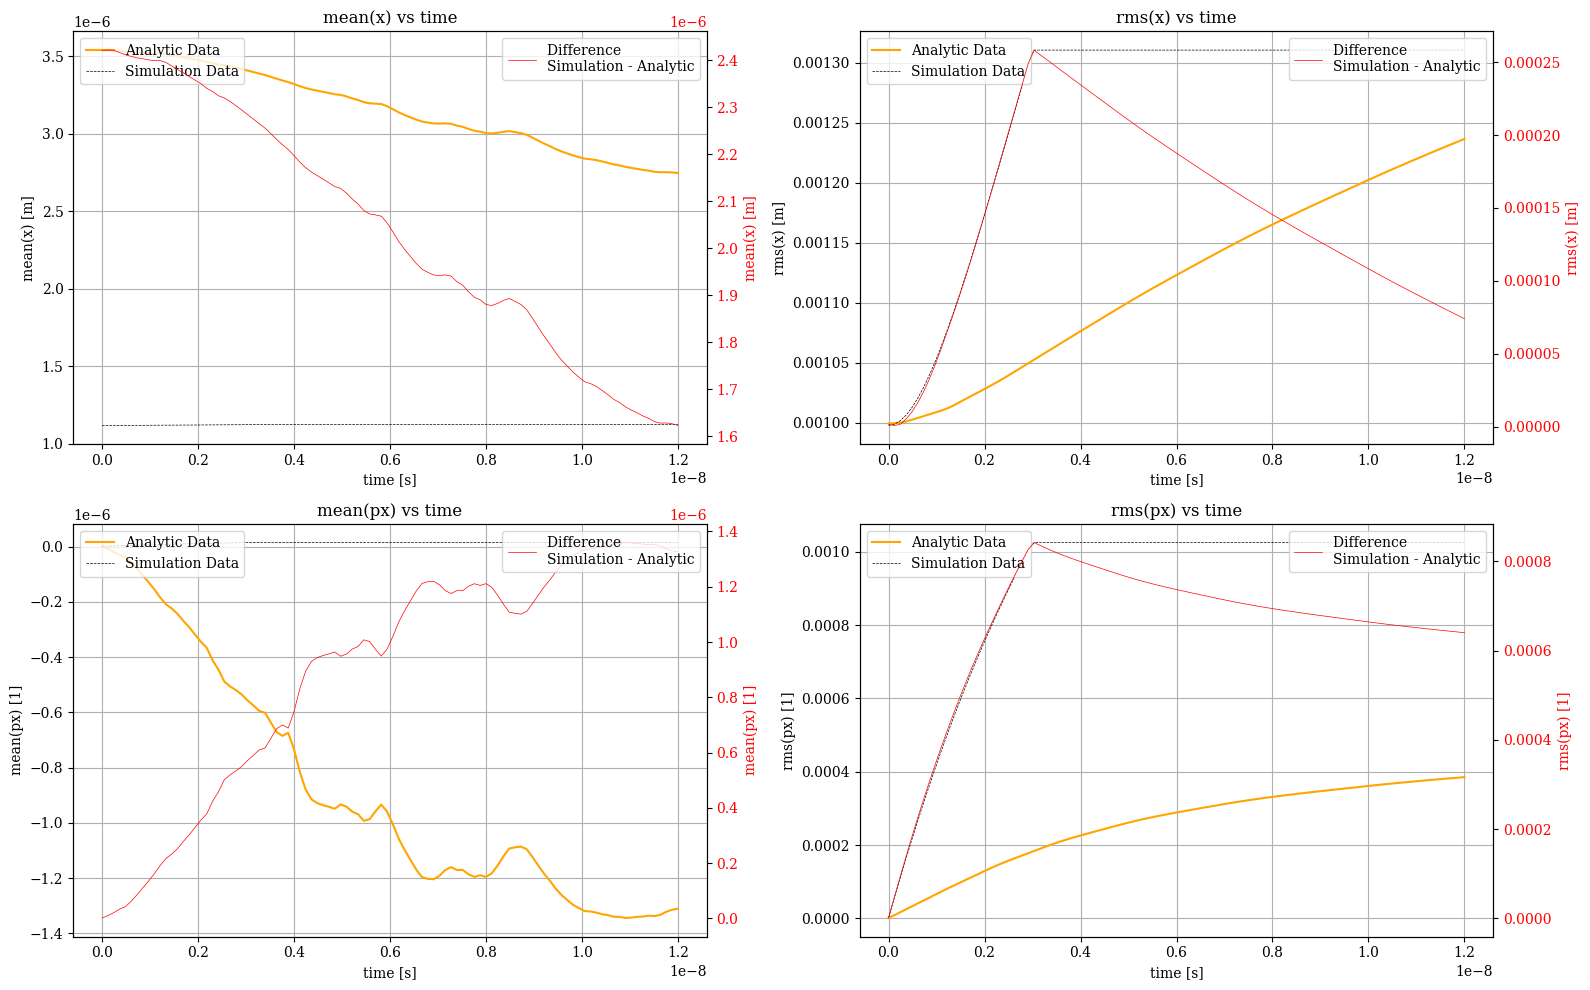

In [21]:
mean_r_t = np.mean(r_t_particles, axis=0)
rms_r_t  = np.std(r_t_particles,  axis=0)
mean_p_t = np.mean(p_t_particles, axis=0)
rms_p_t  = np.std(p_t_particles,  axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Position plots

axes[0,0].plot(times, mean_r_t[:, 0], color='orange', label='Analytic Data')
axes[0,0].set_xlabel('time [s]')
axes[0,0].set_ylabel('mean(x) [m]')
axes[0,0].set_title('mean(x) vs time')
axes[0,0].legend()
axes[0,0].grid()
plot_data(axes[0,0], times, mean_r_t[:, 0], data_times, data_position_means_si[:, 0])

axes[0,1].plot(times, rms_r_t[:, 0], color='orange', label='Analytic Data')
axes[0,1].set_xlabel('time [s]')
axes[0,1].set_ylabel('rms(x) [m]')
axes[0,1].set_title('rms(x) vs time')
axes[0,1].legend()
axes[0,1].grid()
plot_data(axes[0,1], times, rms_r_t[:, 0], data_times, data_position_sigmas_si[:, 0])


## Momentum plots

axes[1,0].plot(times, p_to_betagamma(mean_p_t[:, 0]), color='orange', label='Analytic Data')
axes[1,0].set_xlabel('time [s]')
axes[1,0].set_ylabel('mean(px) [1]')
axes[1,0].set_title('mean(px) vs time')
axes[1,0].legend()
axes[1,0].grid()
plot_data(axes[1,0], times, p_to_betagamma(mean_p_t[:, 0]), data_times, p_to_betagamma(data_momentum_means_pp[:, 0]))

axes[1,1].plot(times, p_to_betagamma(rms_p_t[:, 0]), color='orange', label='Analytic Data')
axes[1,1].set_xlabel('time [s]')
axes[1,1].set_ylabel('rms(px) [1]')
axes[1,1].set_title('rms(px) vs time')
axes[1,1].legend()
axes[1,1].grid()
plot_data(axes[1,1], times, p_to_betagamma(rms_p_t[:, 0]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 0]))

fig.tight_layout()


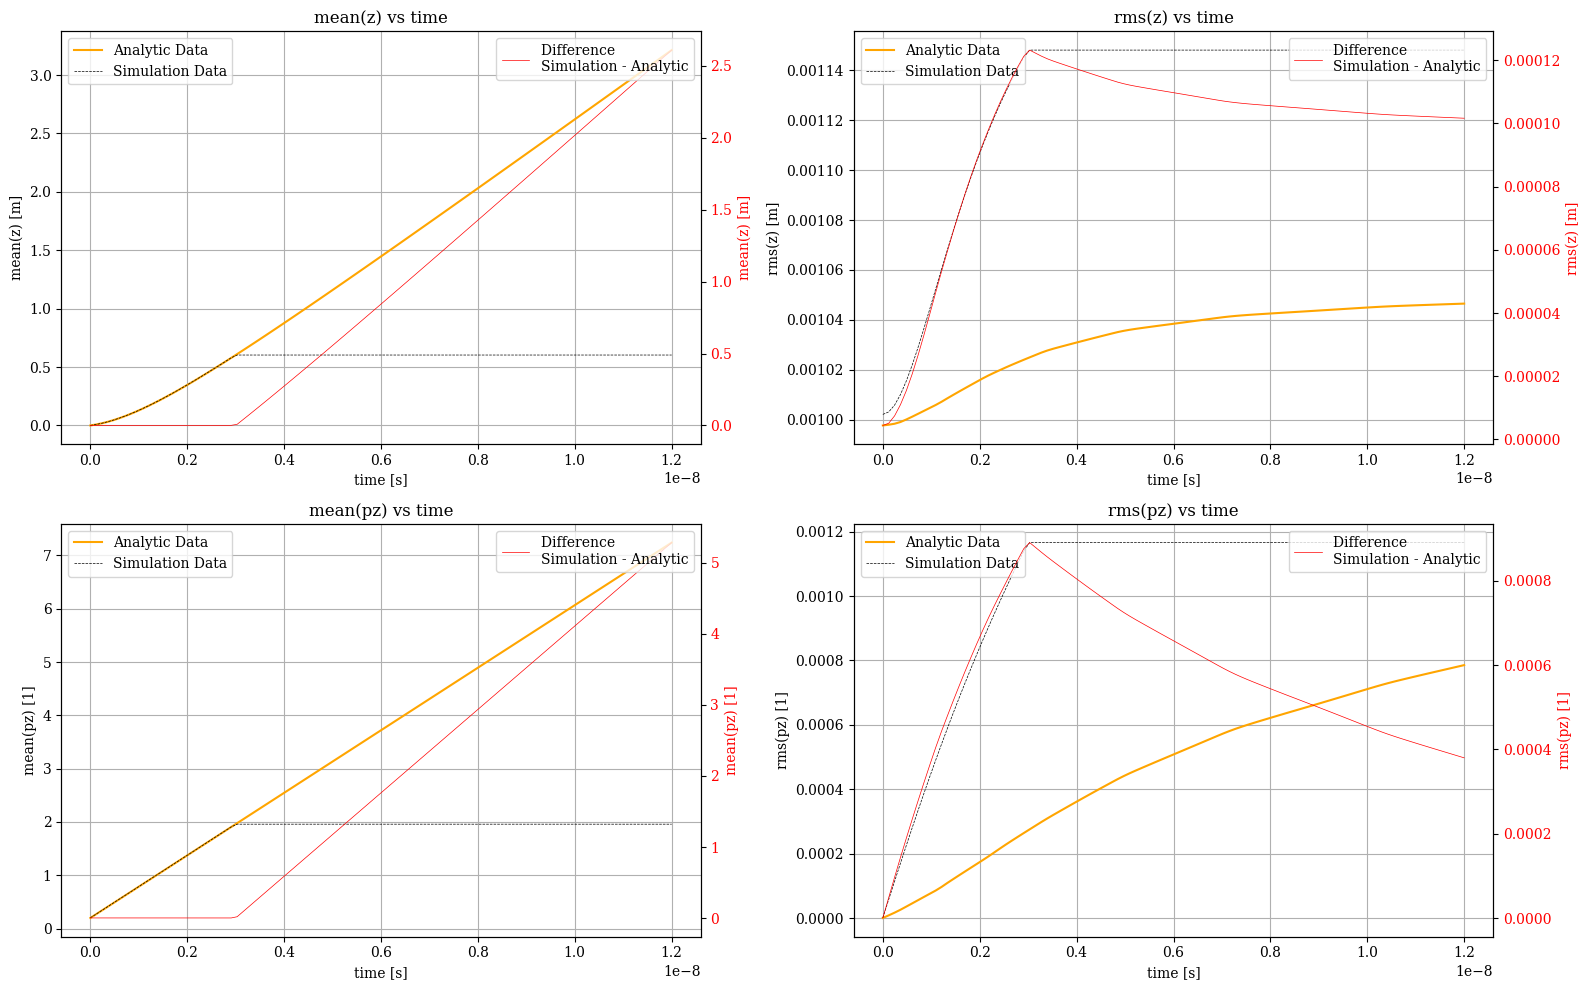

In [22]:


fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Position plots

axes[0,0].plot(times, mean_r_t[:, 2], color='orange', label='Analytic Data')
axes[0,0].set_xlabel('time [s]')
axes[0,0].set_ylabel('mean(z) [m]')
axes[0,0].set_title('mean(z) vs time')
axes[0,0].legend()
axes[0,0].grid()
plot_data(axes[0,0], times, mean_r_t[:,2], data_times, data_position_means_si[:,2])

axes[0,1].plot(times, rms_r_t[:, 2], color='orange', label='Analytic Data')
axes[0,1].set_xlabel('time [s]')
axes[0,1].set_ylabel('rms(z) [m]')
axes[0,1].set_title('rms(z) vs time')
axes[0,1].legend()
axes[0,1].grid()
plot_data(axes[0,1], times, rms_r_t[:,2], data_times, data_position_sigmas_si[:,2])


## Momentum plots

axes[1,0].plot(times, p_to_betagamma(mean_p_t[:, 2]), color='orange', label='Analytic Data')
axes[1,0].set_xlabel('time [s]')
axes[1,0].set_ylabel('mean(pz) [1]')
axes[1,0].set_title('mean(pz) vs time')
axes[1,0].legend()
axes[1,0].grid()
plot_data(axes[1,0], times, p_to_betagamma(mean_p_t[:, 2]), data_times, p_to_betagamma(data_momentum_means_pp[:,2]))

axes[1,1].plot(times, p_to_betagamma(rms_p_t[:, 2]), color='orange', label='Analytic Data')
axes[1,1].set_xlabel('time [s]')
axes[1,1].set_ylabel('rms(pz) [1]')
axes[1,1].set_title('rms(pz) vs time')
axes[1,1].legend()
axes[1,1].grid()
plot_data(axes[1,1], times, p_to_betagamma(rms_p_t[:, 2]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:,2]))

fig.tight_layout()

# Second-order Liénard–Wiechert perturbation

The first-order perturbation $(\mathbf r^{(1)}, \mathbf p^{(1)})$ is now used as a "background" on top
of the zeroth-order trajectory to evaluate the **second**-order corrections,
following the equations listed in `equations.txt`:

$$
\frac{d\mathbf{p}_i^{(2)}}{dt} = q\,\mathbf{E}_{\text{self}}^{(1)}(\mathbf{r}_i, t)
  + q\!\left(\mathbf{v}_i^{(0)}\!\times\!\mathbf{B}_{\text{self}}^{(1)}(\mathbf{r}_i, t)
          + \mathbf{v}_i^{(1)}\!\times\!\mathbf{B}_{\text{self}}^{(0)}(\mathbf{r}_i, t)\right),
$$

$$
\frac{d\mathbf{r}_i^{(2)}}{dt} = \mathbf{v}_i^{(2)}\!\left(\mathbf{p}_i^{(0)},\mathbf{p}_i^{(1)},\mathbf{p}_i^{(2)}\right).
$$

The linearised Liénard–Wiechert fields use the **zeroth-order retarded time**
$t_r^{(0)}$ together with the first-order retarded-time correction

$$
t_{r,ij}^{(1)} = -\,\frac{\mathbf{n}_{ij}^{(0)} \cdot
                       \bigl(\mathbf{r}_i^{(1)}(t) - \mathbf{r}_j^{(1)}(t_r^{(0)})\bigr)}
                      {c\bigl(1 - \mathbf{n}_{ij}^{(0)} \cdot \boldsymbol{\beta}_j^{(0)}\bigr)},
$$

which enters every kinematic and geometric helper used to assemble
$\mathbf E_V^{(1)}$, $\mathbf E_A^{(1)}$, and $\mathbf B^{(1)}$.

In [23]:
# ---------------------------------------------------------------------
# 2nd-order helpers: dense 1st-order interpolants for every particle
# ---------------------------------------------------------------------
#
# The 2nd-order ODE needs, for every source particle ``j``, the value of
# ``r^(1)_j``, ``p^(1)_j``, ``v^(1)_j`` and ``a^(1)_j`` at the (per-source)
# zeroth-order retarded time ``t_r^(0)_ij``.  The first-order solver in
# ``get_1st_order_perturbation`` returned an adaptive time grid per
# particle, so we resample every trajectory onto a common fine grid via
# a cubic-spline interpolation and pre-compute v^(1) and a^(1) from the
# spline derivatives of r^(1).  A simple vectorised linear interpolator
# on this common grid then evaluates all four quantities at the (per-
# source) retarded time during the 2nd-order integration.

from scipy.interpolate import CubicSpline

# Common fine grid used during the 2nd-order integration.
N_T_GRID_2ND = 401
t_grid_2nd   = np.linspace(0.0, T_END, N_T_GRID_2ND)

# Per-particle storage on the common grid.
#   shape  ->  (n_t, N_PARTICLES, 3)
r1_grid_all = np.empty((N_T_GRID_2ND, N_PARTICLES, 3))
p1_grid_all = np.empty((N_T_GRID_2ND, N_PARTICLES, 3))
v1_grid_all = np.empty((N_T_GRID_2ND, N_PARTICLES, 3))   # [m/s]
a1_grid_all = np.empty((N_T_GRID_2ND, N_PARTICLES, 3))   # [m/s^2]

for i in range(N_PARTICLES):
    t_arr  = times1_particles[i]
    # r1_t_particles[i] has shape (3, n_t); transpose for CubicSpline.
    r1_cs  = CubicSpline(t_arr, r1_t_particles[i].T, extrapolate=True)
    p1_cs  = CubicSpline(t_arr, p1_t_particles[i].T, extrapolate=True)

    r1_grid_all[:, i, :] = r1_cs(t_grid_2nd)
    p1_grid_all[:, i, :] = p1_cs(t_grid_2nd)
    # v^(1) = dr^(1)/dt   and   a^(1) = d^2 r^(1)/dt^2   (SI: m/s, m/s^2)
    v1_grid_all[:, i, :] = r1_cs(t_grid_2nd, 1)
    a1_grid_all[:, i, :] = r1_cs(t_grid_2nd, 2)

In [24]:
# ---------------------------------------------------------------------
# Vectorised per-source linear interpolation and analytical 0th-order
# source kinematics (used by the 1st-order field perturbation).
# ---------------------------------------------------------------------

def vec_interp_per_source(t_arr, t_grid, y_grid):
    """Linear interpolation that gives **each** source its own query time.

    Parameters
    ----------
    t_arr : ndarray, shape (N,)
        Per-source query time [s].
    t_grid : ndarray, shape (n_t,)
        Monotonic increasing common time grid [s].
    y_grid : ndarray, shape (n_t, N, 3)
        Per-particle, per-time quantity to interpolate.

    Returns
    -------
    y : ndarray, shape (N, 3)
    """
    idx     = np.searchsorted(t_grid, t_arr, side='right') - 1
    idx     = np.clip(idx, 0, t_grid.size - 2)
    t_left  = t_grid[idx]
    t_right = t_grid[idx + 1]
    w       = ((t_arr - t_left) / (t_right - t_left))[:, None]
    src_idx = np.arange(t_arr.shape[0])
    y_left  = y_grid[idx,     src_idx]
    y_right = y_grid[idx + 1, src_idx]
    return y_left + w * (y_right - y_left)


def kinematics_0th_at_times(t_arr, r0_sources, p0_sources):
    """Vectorised 0th-order trajectory for ``N`` sources at per-source times.

    Returns the position, momentum, Lorentz factor, ``β``, ``β̇``, ``β̈``,
    velocity, acceleration and jerk of every source at its own time.

    Parameters
    ----------
    t_arr : ndarray, shape (N,)
        Per-source query time [s].
    r0_sources, p0_sources : ndarray, shape (N, 3)
        Initial source positions [m] / momenta [MeV/c].

    Returns
    -------
    dict
        Keys ``r``, ``p``, ``gamma``, ``beta``, ``v_si``, ``beta_dot``,
        ``beta_ddot``, ``a_si``, ``a_dot_si``.
    """
    F_z  = Q_E * E_Z * C_SI                                  # [MeV/c per s]
    coef = 1.0 / (Q_E * E_Z)
    px0  = p0_sources[:, 0]
    py0  = p0_sources[:, 1]
    pz0  = p0_sources[:, 2]
    p_perp_sq = px0 * px0 + py0 * py0
    m_perp    = np.sqrt(M_E * M_E + p_perp_sq)
    gamma_0   = np.sqrt(1.0 + (p_perp_sq + pz0 * pz0) / M_E ** 2)
    arsinh_0  = np.arcsinh(pz0 / m_perp)

    pz_t      = pz0 + F_z * t_arr
    gamma_t   = np.sqrt(1.0 + (p_perp_sq + pz_t * pz_t) / M_E ** 2)
    arsinh_d  = np.arcsinh(pz_t / m_perp) - arsinh_0
    dx_src    = (px0 * coef) * arsinh_d
    dy_src    = (py0 * coef) * arsinh_d
    dz_src    = (M_E * coef) * (gamma_t - gamma_0)

    r = np.empty_like(r0_sources, dtype=float)
    r[:, 0] = r0_sources[:, 0] + dx_src
    r[:, 1] = r0_sources[:, 1] + dy_src
    r[:, 2] = r0_sources[:, 2] + dz_src

    p = np.empty_like(r0_sources, dtype=float)
    p[:, 0] = px0
    p[:, 1] = py0
    p[:, 2] = pz_t

    inv_gm = 1.0 / (gamma_t * M_E)
    beta = np.empty_like(r)
    beta[:, 0] = px0  * inv_gm
    beta[:, 1] = py0  * inv_gm
    beta[:, 2] = pz_t * inv_gm
    v_si = beta * C_SI

    # Constant external force [N].
    F_z_si  = (Q_E * E_CHARGE_SI) * (E_Z * 1e6)
    F_dot_b = beta[:, 2] * F_z_si                            # β · F
    inv_mcg = 1.0 / (M_E_SI * C_SI * gamma_t)                # 1 / (γ m c)

    # β̇ = (F − (β·F)β) / (γ m c)
    beta_dot = np.empty_like(r)
    beta_dot[:, 0] = -beta[:, 0] * F_dot_b
    beta_dot[:, 1] = -beta[:, 1] * F_dot_b
    beta_dot[:, 2] = F_z_si - beta[:, 2] * F_dot_b
    beta_dot *= inv_mcg[:, None]

    # β̈ = (−(β̇·F)β − 2(β·F)β̇) / (γ m c)
    Fdot_b_dot = beta_dot[:, 2] * F_z_si                     # β̇ · F
    beta_ddot  = -(Fdot_b_dot[:, None] * beta
                   + 2.0 * F_dot_b[:, None] * beta_dot)
    beta_ddot *= inv_mcg[:, None]

    a_si     = beta_dot  * C_SI                              # dv/dt    [m/s^2]
    a_dot_si = beta_ddot * C_SI                              # d^2v/dt^2 [m/s^3]

    return {
        "r":         r,
        "p":         p,
        "gamma":     gamma_t,
        "beta":      beta,
        "v_si":      v_si,
        "beta_dot":  beta_dot,
        "beta_ddot": beta_ddot,
        "a_si":      a_si,
        "a_dot_si":  a_dot_si,
    }

In [25]:
# ---------------------------------------------------------------------
# 0th-order L–W field together with every intermediate the 1st-order
# field perturbation needs.  Mirrors ``calc_LW_fields`` but additionally
# returns the per-source quantities ``E_V``, ``E_A``, ``n_vec``,
# ``1 − β·n`` etc.
# ---------------------------------------------------------------------

def calc_LW_fields_with_intermediates(t_obs, r_obs, r0_sources, p0_sources):
    """Per-source 0th-order Liénard–Wiechert quantities at the observer.

    Returns a dict with both summed and per-source fields plus all the
    geometric / kinematic intermediates required by
    :func:`calc_LW_fields_1st_order`.
    """
    t_r = t_ret(t_obs, r_obs, r0_sources, p0_sources)                # (N,)

    kin       = kinematics_0th_at_times(t_r, r0_sources, p0_sources)
    r_src     = kin["r"]
    beta_vec  = kin["beta"]
    gamma_src = kin["gamma"]
    beta_dot  = kin["beta_dot"]

    R_vec = r_obs[None, :] - r_src                                   # (N, 3)
    R_mag = np.linalg.norm(R_vec, axis=1)                            # (N,)
    n_vec = R_vec / R_mag[:, None]                                   # (N, 3)

    if USE_CIC_SOFTENING:
        R_mag_soft_sq = R_mag * R_mag + R_SOFT * R_SOFT
        R_mag_soft    = np.sqrt(R_mag_soft_sq)
    else:
        R_mag_soft_sq = R_mag * R_mag
        R_mag_soft    = R_mag

    one_minus_beta_n  = 1.0 - np.einsum("ij,ij->i", beta_vec, n_vec)  # D^(0)
    one_minus_beta_n3 = one_minus_beta_n ** 3

    coul = Q_MACRO_SI / (4.0 * np.pi * EPSILON_0_SI)

    # Per-source velocity (near) field [V/m]
    E_V = coul * (n_vec - beta_vec) / (
        gamma_src[:, None] ** 2
        * one_minus_beta_n3[:, None]
        * R_mag_soft_sq[:, None]
    )

    # Per-source acceleration (radiation) field [V/m]
    cross_accel = np.cross(n_vec - beta_vec, beta_dot)
    E_A = coul * np.cross(n_vec, cross_accel) / (
        C_SI * one_minus_beta_n3[:, None] * R_mag_soft[:, None]
    )

    E_each = E_V + E_A
    B_each = np.cross(n_vec, E_each) / C_SI

    return {
        "t_r":              t_r,
        "kin":              kin,
        "R_vec":            R_vec,
        "R_mag":            R_mag,
        "R_mag_soft":       R_mag_soft,
        "R_mag_soft_sq":    R_mag_soft_sq,
        "n_vec":            n_vec,
        "one_minus_beta_n": one_minus_beta_n,
        "E_V":              E_V,
        "E_A":              E_A,
        "E_each":           E_each,
        "B_each":           B_each,
        "E_tot":            E_each.sum(axis=0),
        "B_tot":            B_each.sum(axis=0),
    }

In [26]:
# ---------------------------------------------------------------------
# 1st-order linearised Liénard–Wiechert field, evaluated at the
# zeroth-order retarded time but including the first-order retarded-
# time correction ``t_r,ij^(1)`` (equations.txt, Sections 3–5).
# ---------------------------------------------------------------------

def calc_LW_fields_1st_order(t_obs, r_obs, r0_sources, p0_sources,
                              r1_obs,
                              r1_grid_src, p1_grid_src,
                              v1_grid_src, a1_grid_src,
                              t_grid):
    """First-order self-field correction at the observer.

    Parameters
    ----------
    t_obs : float
        Observer time [s].
    r_obs : ndarray, shape (3,)
        Observer position at zeroth order [m].
    r0_sources, p0_sources : ndarray, shape (N, 3)
        Initial source positions [m] / momenta [MeV/c]
        (target already removed).
    r1_obs : ndarray, shape (3,)
        Observer 1st-order position perturbation at ``t_obs`` [m].
    r1_grid_src, p1_grid_src : ndarray, shape (n_t, N, 3)
        Pre-evaluated 1st-order source positions [m] / momenta [MeV/c]
        on the common time grid ``t_grid``.
    v1_grid_src, a1_grid_src : ndarray, shape (n_t, N, 3)
        Pre-evaluated 1st-order source velocities [m/s] and accelerations
        [m/s^2] on the same grid.
    t_grid : ndarray, shape (n_t,)
        Common time grid for the 1st-order grids.

    Returns
    -------
    dict with keys ``E0_tot``, ``B0_tot``, ``E1_tot``, ``B1_tot`` [V/m, T].
    """
    bg = calc_LW_fields_with_intermediates(t_obs, r_obs, r0_sources, p0_sources)
    t_r        = bg["t_r"]
    R_mag0     = bg["R_mag"]
    n_vec0     = bg["n_vec"]
    D0         = bg["one_minus_beta_n"]                 # 1 − β^(0)·n^(0)
    kin        = bg["kin"]
    gamma0     = kin["gamma"]
    beta0      = kin["beta"]
    beta_dot0  = kin["beta_dot"]
    v_si0      = kin["v_si"]
    a_si0      = kin["a_si"]
    a_dot_si0  = kin["a_dot_si"]
    p0_src     = kin["p"]

    # ---- 1st-order source kinematics at t_r^(0) (per-source) -----------
    r1_src = vec_interp_per_source(t_r, t_grid, r1_grid_src)        # [m]
    p1_src = vec_interp_per_source(t_r, t_grid, p1_grid_src)        # [MeV/c]
    v1_src = vec_interp_per_source(t_r, t_grid, v1_grid_src)        # [m/s]
    a1_src = vec_interp_per_source(t_r, t_grid, a1_grid_src)        # [m/s^2]

    # γ^(1)_j = (p^(0) · p^(1)) / (m^2 c^2 γ^(0))   (in c=1 hybrid: m c -> M_E)
    p0_dot_p1 = np.einsum("ij,ij->i", p0_src, p1_src)
    gamma1    = p0_dot_p1 / (M_E ** 2 * gamma0)                      # (N,)

    # ---- 1st-order retarded-time correction (Eq. 3) --------------------
    delta_r1 = r1_obs[None, :] - r1_src                              # (N, 3)
    n_dot_dr = np.einsum("ij,ij->i", n_vec0, delta_r1)               # (N,)
    t_r1     = -n_dot_dr / (C_SI * D0)                                # (N,) [s]

    # ---- R^(1) vector / scalar and n^(1) (Eq. 4) -----------------------
    R1_vec = delta_r1 - v_si0 * t_r1[:, None]                         # (N, 3)
    R1_scl = -C_SI * t_r1                                             # (N,)
    n1_vec = (R1_vec - R1_scl[:, None] * n_vec0) / R_mag0[:, None]    # (N, 3)

    # β^(1)_j  =  (1/c)[v^(1)_j(t_r^(0)) + a^(0)_j(t_r^(0)) · t_r,ij^(1)]
    beta1 = (v1_src + a_si0 * t_r1[:, None]) / C_SI                   # (N, 3)
    # β̇^(1)_j  =  (1/c)[a^(1)_j(t_r^(0)) + ȧ^(0)_j(t_r^(0)) · t_r,ij^(1)]
    beta_dot1 = (a1_src + a_dot_si0 * t_r1[:, None]) / C_SI           # (N, 3)

    # ---- D^(1) (Nennerstörung) ----------------------------------------
    D1 = -(np.einsum("ij,ij->i", beta1, n_vec0)
           + np.einsum("ij,ij->i", beta0, n1_vec))                    # (N,)

    # Effective (possibly softened) R quantities for the prefactors.
    if USE_CIC_SOFTENING:
        R0_eff_sq = bg["R_mag_soft_sq"]
        R0_eff    = bg["R_mag_soft"]
    else:
        R0_eff_sq = R_mag0 * R_mag0
        R0_eff    = R_mag0

    coul = Q_MACRO_SI / (4.0 * np.pi * EPSILON_0_SI)

    # ---- 1st-order velocity field (Eq. 5, "E_V") -----------------------
    bracket_V = (
        - 2.0 * gamma1 / gamma0
        - 2.0 * R1_scl / R_mag0
        - 3.0 * D1     / D0
    )                                                                 # (N,)
    E_V1 = bg["E_V"] * bracket_V[:, None] + (
        coul / (gamma0[:, None] ** 2
                * R0_eff_sq[:, None]
                * D0[:, None] ** 3)
    ) * (n1_vec - beta1)                                              # (N, 3)

    # ---- 1st-order acceleration field (Eq. 5, "E_A") -------------------
    bracket_A = (- R1_scl / R_mag0 - 3.0 * D1 / D0)                   # (N,)

    cross_t1 = np.cross(n1_vec, np.cross(n_vec0 - beta0, beta_dot0))
    cross_t2 = np.cross(n_vec0, np.cross(n1_vec - beta1, beta_dot0))
    cross_t3 = np.cross(n_vec0, np.cross(n_vec0 - beta0, beta_dot1))
    cross_sum = cross_t1 + cross_t2 + cross_t3                        # (N, 3)

    E_A1 = bg["E_A"] * bracket_A[:, None] + (
        coul / (C_SI * R0_eff[:, None] * D0[:, None] ** 3)
    ) * cross_sum                                                     # (N, 3)

    E_each1 = E_V1 + E_A1
    # B^(1)_ij = (1/c) (n^(1) × E^(0) + n^(0) × E^(1))
    B_each1 = (np.cross(n1_vec, bg["E_each"])
               + np.cross(n_vec0, E_each1)) / C_SI

    return {
        "E0_tot": bg["E_tot"],
        "B0_tot": bg["B_tot"],
        "E1_tot": E_each1.sum(axis=0),
        "B1_tot": B_each1.sum(axis=0),
    }

In [27]:
# ---------------------------------------------------------------------
# Second-order perturbation ODE integrator for one target particle.
# ---------------------------------------------------------------------

def get_2nd_order_perturbation(t_end, target_idx):
    """Integrate the 2nd-order position and momentum perturbation.

    The first-order field perturbation enters via the linearised L–W
    expression :func:`calc_LW_fields_1st_order`, which itself uses the
    pre-computed dense interpolants ``r1_grid_all``, ``p1_grid_all``,
    ``v1_grid_all``, ``a1_grid_all`` (built in the helper cell above).

    Parameters
    ----------
    t_end : float
        Integration end time [s].
    target_idx : int
        Index of the target particle within ``r0_particles``.

    Returns
    -------
    t : ndarray
        Adaptive solver time grid [s].
    r2_t : ndarray, shape (3, len(t))
        Second-order position perturbation [m].
    p2_t : ndarray, shape (3, len(t))
        Second-order momentum perturbation [MeV/c].
    """
    r0_target = r0_particles[target_idx]
    p0_target = p0_particles[target_idx]

    # Self-exclusion (consistent with the 1st-order routine).
    same_r = np.all(np.isclose(r0_particles, r0_target), axis=1)
    same_p = np.all(np.isclose(p0_particles, p0_target), axis=1)
    is_self    = same_r & same_p
    keep       = ~is_self

    r0_src_eff = r0_particles[keep]
    p0_src_eff = p0_particles[keep]
    r1_grid_eff = r1_grid_all[:, keep, :]
    p1_grid_eff = p1_grid_all[:, keep, :]
    v1_grid_eff = v1_grid_all[:, keep, :]
    a1_grid_eff = a1_grid_all[:, keep, :]

    # Dense splines for the target's own 1st-order trajectory.
    r1_target_cs = CubicSpline(t_grid_2nd, r1_grid_all[:, target_idx, :],
                                extrapolate=True)
    p1_target_cs = CubicSpline(t_grid_2nd, p1_grid_all[:, target_idx, :],
                                extrapolate=True)
    v1_target_cs = r1_target_cs.derivative(1)                      # m/s

    # Unit conversions, identical to the 1st-order solver.
    p_si_per_hybrid = (1e6 * E_CHARGE_SI) / C_SI         # [kg·m/s per (MeV/c)]
    q_target_si     = Q_E * E_CHARGE_SI                  # one test electron [C]

    def perturbation2_derivatives(t, Y):
        # State Y = [p2_x, p2_y, p2_z, r2_x, r2_y, r2_z].
        p2 = Y[0:3]

        # 0th-order kinematics of the target.
        r0_t, p0_t, gamma0_t = get_0th_trajectory(t, r0_target, p0_target)
        v0_si = (p0_t / (gamma0_t * M_E)) * C_SI                    # [m/s]

        # 1st-order kinematics of the target (single scalar time).
        r1_t  = r1_target_cs(t)                                     # [m]
        p1_t  = p1_target_cs(t)                                     # [MeV/c]
        v1_si = v1_target_cs(t)                                     # [m/s]

        # 0th- and 1st-order self-fields at the observer.
        flds = calc_LW_fields_1st_order(
            t, r0_t, r0_src_eff, p0_src_eff,
            r1_t,
            r1_grid_eff, p1_grid_eff, v1_grid_eff, a1_grid_eff,
            t_grid_2nd,
        )
        E0_si = flds["E0_tot"]; B0_si = flds["B0_tot"]
        E1_si = flds["E1_tot"]; B1_si = flds["B1_tot"]

        # 2nd-order Lorentz force on the target (equations.txt, Sec. 2).
        F_si = q_target_si * (
            E1_si
            + np.cross(v0_si, B1_si)
            + np.cross(v1_si, B0_si)
        )
        dp2_dt = F_si / p_si_per_hybrid                              # [MeV/c per s]

        # 2nd-order velocity (equations.txt, Sec. 1) in c=1 hybrid units.
        m_gamma    = M_E * gamma0_t
        m_gamma_sq = m_gamma * m_gamma                               # M_E^2 γ^2
        m_gamma_qd = m_gamma_sq * m_gamma_sq                         # M_E^4 γ^4
        p0_dot_p2  = np.dot(p0_t, p2)
        p0_dot_p1  = np.dot(p0_t, p1_t)
        p1_sq      = np.dot(p1_t, p1_t)

        term1 = -((p0_dot_p2 + 0.5 * p1_sq) / m_gamma_sq) * p0_t
        term2 = -(p0_dot_p1 / m_gamma_sq) * p1_t
        term3 =  (1.5 * p0_dot_p1 ** 2 / m_gamma_qd) * p0_t

        v2_hybrid = (p2 + term1 + term2 + term3) / m_gamma           # c-units
        dr2_dt    = v2_hybrid * C_SI                                  # [m/s]

        return np.concatenate((dp2_dt, dr2_dt))

    Y0 = np.zeros(6)
    sol = solve_ivp(
        perturbation2_derivatives,
        [0.0, t_end],
        Y0,
        method='RK45',
        rtol=1e-6,
        atol=1e-9,
    )
    p2_t = sol.y[0:3, :]
    r2_t = sol.y[3:6, :]
    return sol.t, r2_t, p2_t

In [28]:
# ---------------------------------------------------------------------
# Run the 2nd-order computation in parallel for every target.
# ---------------------------------------------------------------------

def _solve_one_target_2nd(target_idx):
    return get_2nd_order_perturbation(T_END, target_idx)

results_2nd = Parallel(n_jobs=-1, prefer="threads", verbose=10)(
    delayed(_solve_one_target_2nd)(i) for i in range(N_PARTICLES)
)

times2_particles = [r[0] for r in results_2nd]
r2_t_particles   = [r[1] for r in results_2nd]
p2_t_particles   = [r[2] for r in results_2nd]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   31.6s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:   35.6s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:   45.0s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:   51.2s
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elaps

In [29]:
# ---------------------------------------------------------------------
# Combine 0th + 1st + 2nd order on the existing ``times`` plotting grid.
# ---------------------------------------------------------------------

r_t_particles_2 = np.zeros((N_PARTICLES, len(times), 3))   # [m]
p_t_particles_2 = np.zeros((N_PARTICLES, len(times), 3))   # [MeV/c]

for target_idx in range(N_PARTICLES):
    r0_init = r0_particles[target_idx]
    p0_init = p0_particles[target_idx]

    t1, r1_t, p1_t = (
        times1_particles[target_idx],
        r1_t_particles[target_idx],
        p1_t_particles[target_idx],
    )
    t2, r2_t, p2_t = (
        times2_particles[target_idx],
        r2_t_particles[target_idx],
        p2_t_particles[target_idx],
    )

    for k in range(3):
        r1_int = np.interp(times, t1, r1_t[k, :])
        p1_int = np.interp(times, t1, p1_t[k, :])
        r2_int = np.interp(times, t2, r2_t[k, :])
        p2_int = np.interp(times, t2, p2_t[k, :])
        for t_idx, t in enumerate(times):
            r0_t, p0_t, _ = get_0th_trajectory(t, r0_init, p0_init)
            r_t_particles_2[target_idx, t_idx, k] = (
                r0_t[k] + r1_int[t_idx] + r2_int[t_idx]
            )
            p_t_particles_2[target_idx, t_idx, k] = (
                p0_t[k] + p1_int[t_idx] + p2_int[t_idx]
            )

mean_r_t_2 = np.mean(r_t_particles_2, axis=0)
rms_r_t_2  = np.std(r_t_particles_2,  axis=0)
mean_p_t_2 = np.mean(p_t_particles_2, axis=0)
rms_p_t_2  = np.std(p_t_particles_2,  axis=0)

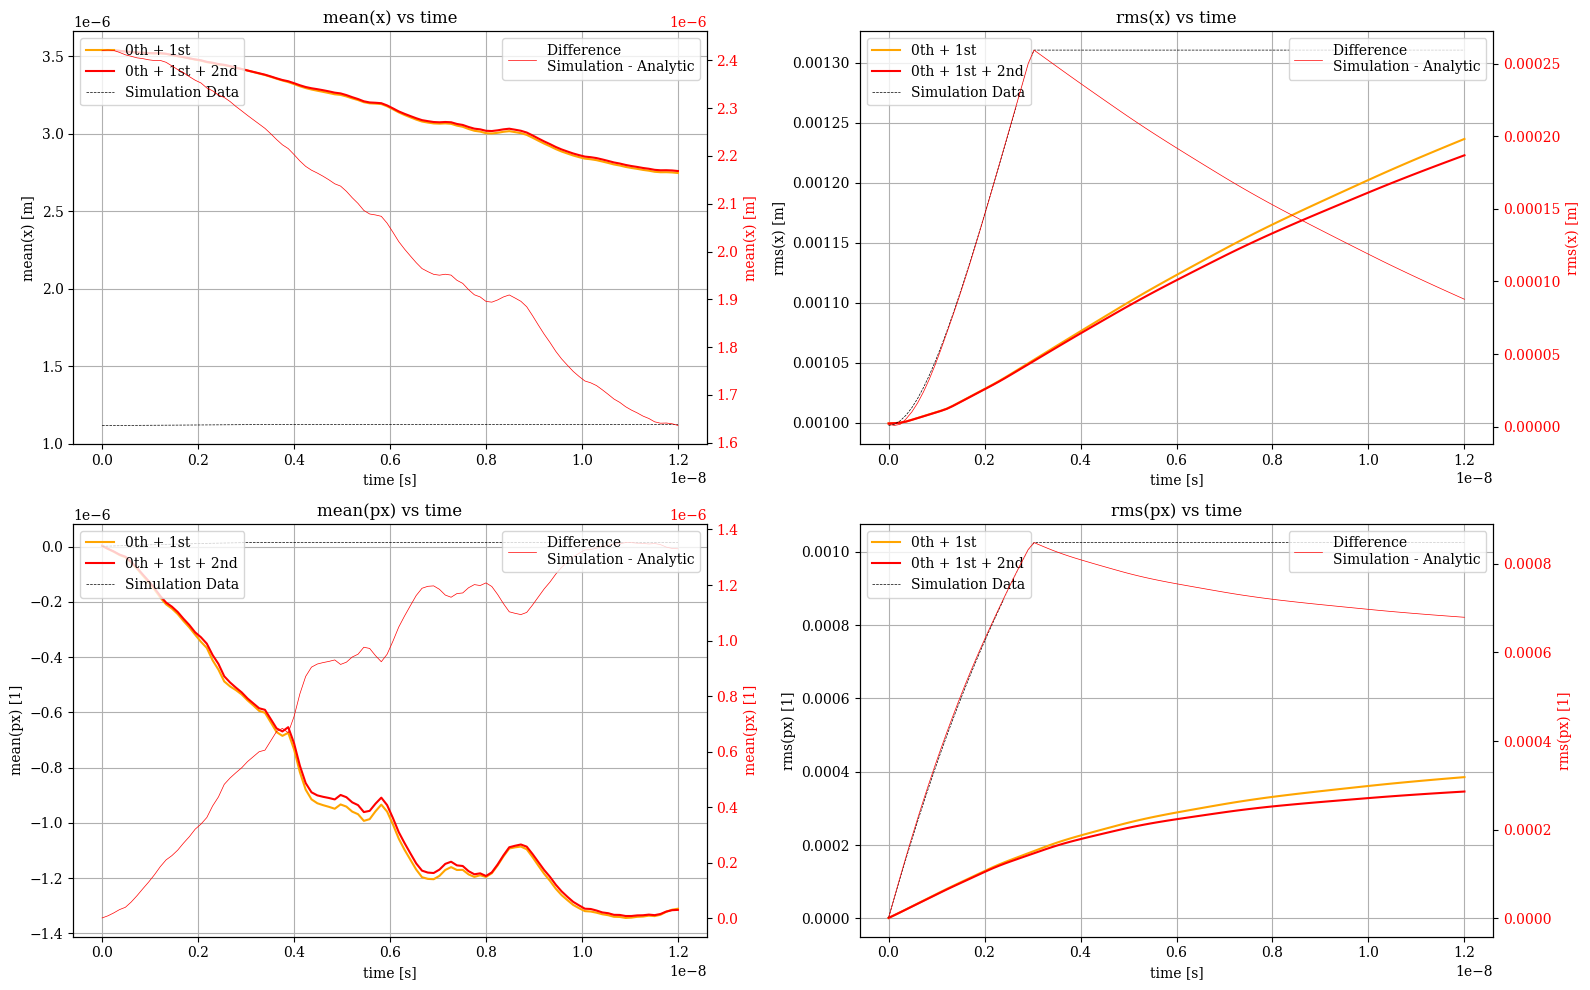

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Position plots: x including the 2nd-order correction

axes[0,0].plot(times, mean_r_t[:,   0], color='orange', label='0th + 1st')
axes[0,0].plot(times, mean_r_t_2[:, 0], color='red',    label='0th + 1st + 2nd')
axes[0,0].set_xlabel('time [s]')
axes[0,0].set_ylabel('mean(x) [m]')
axes[0,0].set_title('mean(x) vs time')
axes[0,0].legend()
axes[0,0].grid()
plot_data(axes[0,0], times, mean_r_t_2[:, 0], data_times, data_position_means_si[:, 0])

axes[0,1].plot(times, rms_r_t[:,   0], color='orange', label='0th + 1st')
axes[0,1].plot(times, rms_r_t_2[:, 0], color='red',    label='0th + 1st + 2nd')
axes[0,1].set_xlabel('time [s]')
axes[0,1].set_ylabel('rms(x) [m]')
axes[0,1].set_title('rms(x) vs time')
axes[0,1].legend()
axes[0,1].grid()
plot_data(axes[0,1], times, rms_r_t_2[:, 0], data_times, data_position_sigmas_si[:, 0])


# Momentum plots: px including the 2nd-order correction

axes[1,0].plot(times, p_to_betagamma(mean_p_t[:,   0]), color='orange', label='0th + 1st')
axes[1,0].plot(times, p_to_betagamma(mean_p_t_2[:, 0]), color='red',    label='0th + 1st + 2nd')
axes[1,0].set_xlabel('time [s]')
axes[1,0].set_ylabel('mean(px) [1]')
axes[1,0].set_title('mean(px) vs time')
axes[1,0].legend()
axes[1,0].grid()
plot_data(axes[1,0], times, p_to_betagamma(mean_p_t_2[:, 0]),
          data_times, p_to_betagamma(data_momentum_means_pp[:, 0]))

axes[1,1].plot(times, p_to_betagamma(rms_p_t[:,   0]), color='orange', label='0th + 1st')
axes[1,1].plot(times, p_to_betagamma(rms_p_t_2[:, 0]), color='red',    label='0th + 1st + 2nd')
axes[1,1].set_xlabel('time [s]')
axes[1,1].set_ylabel('rms(px) [1]')
axes[1,1].set_title('rms(px) vs time')
axes[1,1].legend()
axes[1,1].grid()
plot_data(axes[1,1], times, p_to_betagamma(rms_p_t_2[:, 0]),
          data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 0]))

fig.tight_layout()

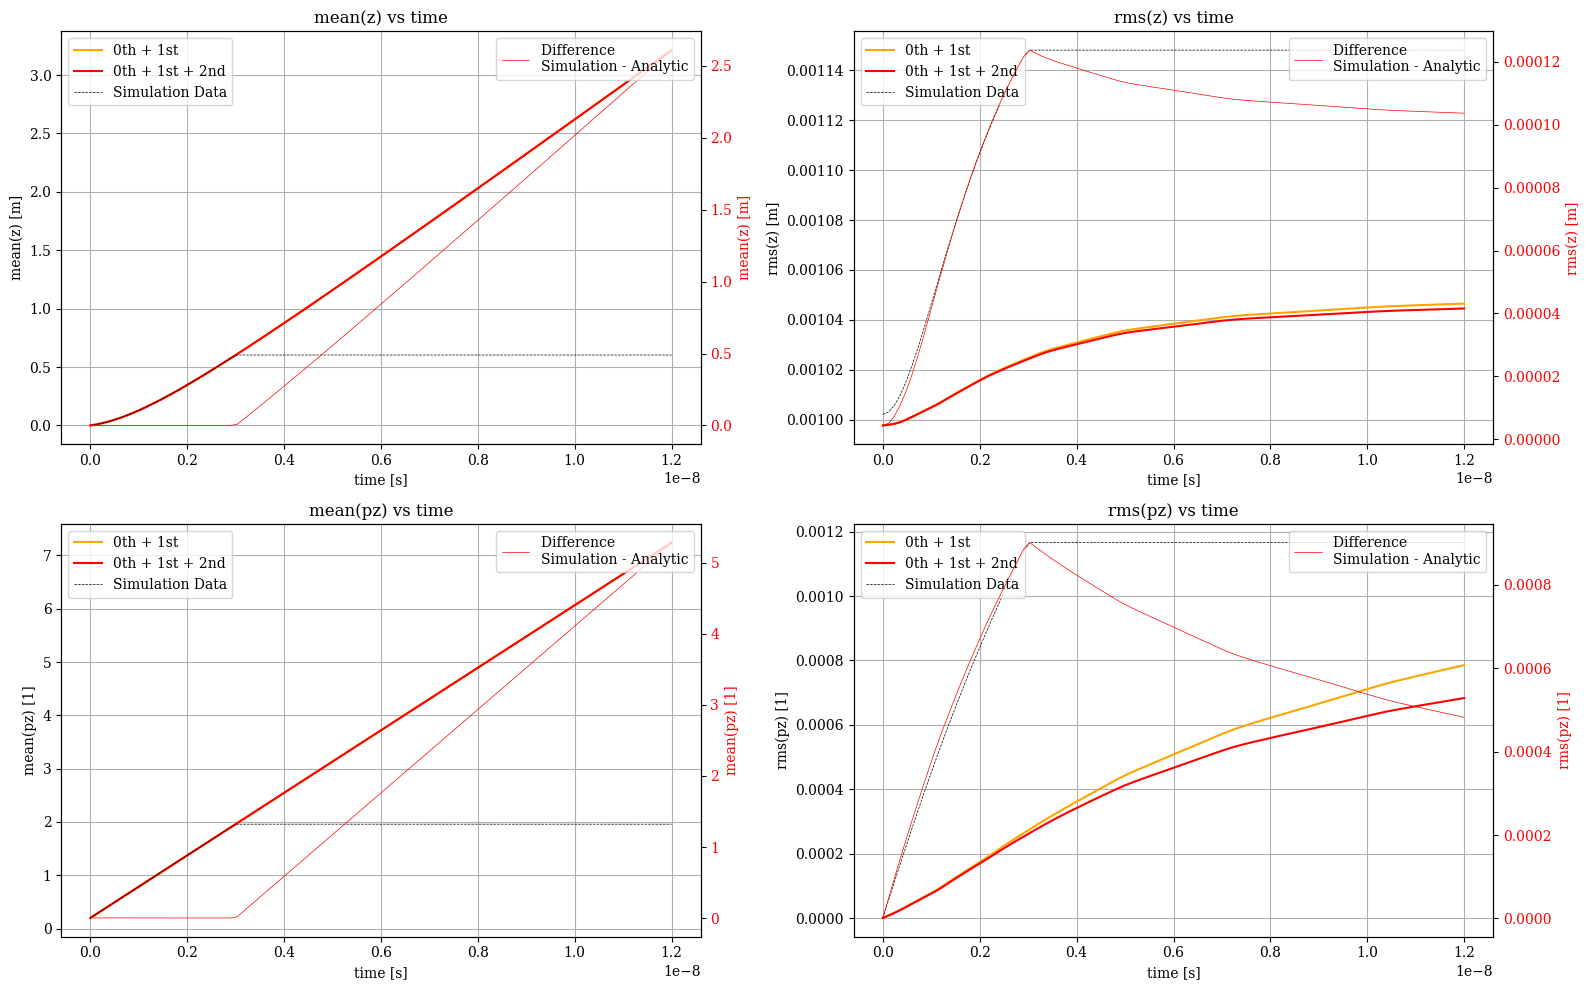

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Position plots: z including the 2nd-order correction

axes[0,0].plot(times, mean_r_t[:,   2], color='orange', label='0th + 1st')
axes[0,0].plot(times, mean_r_t_2[:, 2], color='red',    label='0th + 1st + 2nd')
axes[0,0].set_xlabel('time [s]')
axes[0,0].set_ylabel('mean(z) [m]')
axes[0,0].set_title('mean(z) vs time')
axes[0,0].legend()
axes[0,0].grid()
plot_data(axes[0,0], times, mean_r_t_2[:, 2], data_times, data_position_means_si[:, 2])

axes[0,1].plot(times, rms_r_t[:,   2], color='orange', label='0th + 1st')
axes[0,1].plot(times, rms_r_t_2[:, 2], color='red',    label='0th + 1st + 2nd')
axes[0,1].set_xlabel('time [s]')
axes[0,1].set_ylabel('rms(z) [m]')
axes[0,1].set_title('rms(z) vs time')
axes[0,1].legend()
axes[0,1].grid()
plot_data(axes[0,1], times, rms_r_t_2[:, 2], data_times, data_position_sigmas_si[:, 2])


# Momentum plots: pz including the 2nd-order correction

axes[1,0].plot(times, p_to_betagamma(mean_p_t[:,   2]), color='orange', label='0th + 1st')
axes[1,0].plot(times, p_to_betagamma(mean_p_t_2[:, 2]), color='red',    label='0th + 1st + 2nd')
axes[1,0].set_xlabel('time [s]')
axes[1,0].set_ylabel('mean(pz) [1]')
axes[1,0].set_title('mean(pz) vs time')
axes[1,0].legend()
axes[1,0].grid()
plot_data(axes[1,0], times, p_to_betagamma(mean_p_t_2[:, 2]),
          data_times, p_to_betagamma(data_momentum_means_pp[:, 2]))

axes[1,1].plot(times, p_to_betagamma(rms_p_t[:,   2]), color='orange', label='0th + 1st')
axes[1,1].plot(times, p_to_betagamma(rms_p_t_2[:, 2]), color='red',    label='0th + 1st + 2nd')
axes[1,1].set_xlabel('time [s]')
axes[1,1].set_ylabel('rms(pz) [1]')
axes[1,1].set_title('rms(pz) vs time')
axes[1,1].legend()
axes[1,1].grid()
plot_data(axes[1,1], times, p_to_betagamma(rms_p_t_2[:, 2]),
          data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 2]))

fig.tight_layout()

In [32]:
from pathlib import Path

REPORT_DATA_DIR = Path("release_data") / "data"
REPORT_DATA_DIR.mkdir(parents=True, exist_ok=True)

REPORT_COLUMNS = (
    "time_s",
    "mean_x_m", "mean_y_m", "mean_z_m",
    "rms_x_m", "rms_y_m", "rms_z_m",
    "mean_px_beta_gamma", "mean_py_beta_gamma", "mean_pz_beta_gamma",
    "rms_px_beta_gamma", "rms_py_beta_gamma", "rms_pz_beta_gamma",
)


def save_report_data(filename, time_s, mean_r, rms_r, mean_p, rms_p):
    data = np.column_stack((
        time_s,
        mean_r[:, 0], mean_r[:, 1], mean_r[:, 2],
        rms_r[:, 0], rms_r[:, 1], rms_r[:, 2],
        p_to_betagamma(mean_p[:, 0]),
        p_to_betagamma(mean_p[:, 1]),
        p_to_betagamma(mean_p[:, 2]),
        p_to_betagamma(rms_p[:, 0]),
        p_to_betagamma(rms_p[:, 1]),
        p_to_betagamma(rms_p[:, 2]),
    ))
    np.savetxt(
        REPORT_DATA_DIR / filename,
        data,
        delimiter=",",
        header=",".join(REPORT_COLUMNS),
        comments="",
    )


save_report_data("simple_1st_order_perturbation.csv", times, mean_r_t, rms_r_t, mean_p_t, rms_p_t)
save_report_data("simple_2nd_order_perturbation.csv", times, mean_r_t_2, rms_r_t_2, mean_p_t_2, rms_p_t_2)